# Preliminary snRNAseq analysis
- data generated on 12/18/26
- isolated tissue from OMC of lab mouse, sorted on DAPI -> 10x
- generated ~10,000 cells

- Mostly followed the [basic tutorial from scanpy](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html) to get started


Suggested reading:
- [Single Cell Best practices GitBook](https://www.sc-best-practices.org/preamble.html)

In [ ]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# snRNAseq
import anndata as ad
import scanpy as sc

# for calc MAD
from scipy.stats import median_abs_deviation



# Initial exploration

In [ ]:
# specify paths
home_path = "/Volumes/S2D1/"
filt_expr_path = home_path +"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/count/Banerjee_EI02_LM/outs/filtered_feature_bc_matrix.h5"
save_path = home_path+"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/figs"

- uses [anndata](https://anndata.readthedocs.io/en/stable/tutorials/notebooks/getting-started.html) objects

In [ ]:
adata = sc.read_10x_h5(filt_expr_path)
adata.var_names_make_unique()
adata.var_keys

In [ ]:
expr = adata.to_df()


In [ ]:
expr_n0 = expr.replace(0, np.nan) # replace 0 w/ nan

# drop gene columns where don't detect gene counts
gene_0_idx = expr_n0.sum()==0
gene_0 = expr_n0.columns[gene_0_idx].to_list()
expr_n0 = expr_n0.drop(gene_0, axis=1)

# flattened list of all expression values
expr_vals = expr_n0.to_numpy().flatten()
expr_vals = expr_vals[~np.isnan(expr_vals)]

# sum of all gene counts per cell
cell_counts = expr_n0.sum(axis=1)

# sum of expressed genes per cell
gene_counts = (expr_n0>0).sum(axis=1)

# percent of cells expressing gene
pcells = (((expr_n0>0).sum(axis=0))/expr_n0.shape[0]) * 100


In [ ]:
# summary statistics

# number of cells
print("Number of cells:", adata.obs.shape[0])


# number of genes
print("Number of genes:", adata.var.shape[0])
print("Number of non-zero genes:", expr_n0.shape[1])


fig, axs = plt.subplots(2,2, figsize=(12,10))
# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)


######## GENE COUNTS PER CELL (exclude 0s)

log_bins = np.logspace(0,4, 15)
axs[0,0].hist(expr_vals, bins=log_bins)
axs[0,0].set_xscale('log')
axs[0,0].set_xlabel("Raw gene count")
axs[0,0].set_ylabel("Frequency")


textstr = '\n'.join((
    'Individual gene counts per cell',
    f"\tRange: {expr_vals.max():.2f} - {expr_vals.min():.2f}",
    f"\tMean +/- std: {expr_vals.mean():.2f} +/- {expr_vals.std():.2f}",
    f"\tMedian: {np.median(expr_vals):.2f}"
))

# textbox
axs[0,0].text(0.25, 0.95, textstr, transform=axs[0,0].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)




##### SUMMED GENE COUNTS PER CELL

axs[0,1].hist(cell_counts)
axs[0,1].set_xlabel("Summed total gene counts per cell")
axs[0,1].set_ylabel("Frequency")

# stats on summed gene counts per cell

textstr = '\n'.join((
    'Summed gene counts per cell',
    f"\tRange: {cell_counts.max():.2f} - {cell_counts.min():.2f}",
    f"\tMean +/- std: {cell_counts.mean():.2f} +/- {cell_counts.std():.2f}",
    f"\tMedian: {np.median(cell_counts):.2f}"
))

# textbox
axs[0,1].text(0.25, 0.95, textstr, transform=axs[0,1].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)





###### NUMBER OF EXPRESSED GENES PER CELL

axs[1,0].hist(gene_counts)
axs[1,0].set_xlabel("# expressed genes per cell")
axs[1,0].set_ylabel("Frequency")

textstr = '\n'.join((
    'Summed gene counts per cell',
    f"\tRange: {gene_counts.max():.2f} - {gene_counts.min():.2f}",
    f"\tMean +/- std: {gene_counts.mean():.2f} +/- {gene_counts.std():.2f}",
    f"\tMedian: {np.median(gene_counts):.2f}"
))

# textbox
axs[1,0].text(0.25, 0.95, textstr, transform=axs[1,0].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)


##### PERCENT OF CELLS EXPRESSING GENE

axs[1,1].hist(pcells)
axs[1,1].set_xlabel("Percent of cells per gene")
axs[1,1].set_ylabel("Frequency")

textstr = '\n'.join((
    'Percent of cells per gene',
    f"\tRange: {pcells.max():.2f} - {pcells.min():.2f}",
    f"\tMean +/- std: {pcells.mean():.2f} +/- {pcells.std():.2f}",
    f"\tMedian: {pcells.median():.2f}"
))

# textbox
axs[1,1].text(0.25, 0.95, textstr, transform=axs[1,1].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

plt.show()

In [ ]:
# sigmoidal relation b/w expr level and freq in cells

avg_gene_expr = expr_n0.mean()

pcells

plt.scatter(avg_gene_expr, pcells)
plt.xscale('log')
plt.xlabel("Average gene expression per cell")
plt.ylabel("Percent cells expressed")
plt.show()





# Quality control

- QC metrics taken from [McCarthy et al., 2017](https://doi.org/10.1093/bioinformatics/btw777)
- based on scater package in R/Bioconductor

In [ ]:
# load paths
home_path = "/Volumes/S2D1/"
filt_expr_path = home_path +"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/count/Banerjee_EI02_LM/outs/filtered_feature_bc_matrix.h5"
raw_expr_path = home_path +"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/count/Banerjee_EI02_LM/outs/raw_feature_bc_matrix.h5"
save_path = home_path+"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/figs"


In [ ]:
# load data
adata = sc.read_10x_h5(filt_expr_path)
adata.var_names_make_unique()


adata

In [ ]:
# get list of mt, rb, hb genes

# 13 mitochondrial genes
mito_idx = adata.var.index.str.startswith("mt")
mito = adata.var.index[mito_idx]
print(mito)
print(f"{len(mito)} mito genes")

# ribo genes
ribo_idx = adata.var.index.str.startswith(("Rps", "Rpl"))
ribo = adata.var.index[ribo_idx]
print("\n",ribo)
print(f"{len(ribo)} ribo genes")

# Hemoglobin genes
hemo_idx = adata.var.index.str.contains("Hb[^spe]")
hemo = adata.var.index[hemo_idx]
print("\n",hemo)
print(f"{len(hemo)} hemo genes")



In [ ]:
# label mt, rb, hb genes

# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("mt-")

# Ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("Hb[^spe]")

In [ ]:
# Calculate QC metrics
# note: log1p = natural log of x+1
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], 
                           inplace=True, log1p=True, percent_top=[20])
adata.var_keys

## QC plots

In [ ]:
# Plot - histograms

# sns.jointplot(
#     data=adata.obs,
#     x="total_counts",
#     y="n_genes_by_counts",
#     kind="hex"
#     )

# plt.show()

# sns.jointplot(
#     data=adata.obs,
#     x="log1p_total_counts",
#     y="log1p_n_genes_by_counts",
#     kind="hex"
#     )

# plt.show()

fig, axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(adata.obs["total_counts"], ax=axs[0,0])
axs[0,0].set_title("Total number of counts for a cell")

sns.histplot(adata.obs["n_genes_by_counts"], ax=axs[0,1])
axs[0,1].set_title("Number of unique genes expressed in cells")

sns.histplot(adata.obs["log1p_total_counts"], ax=axs[1,0])

sns.histplot(adata.obs["log1p_n_genes_by_counts"], ax=axs[1,1])

plt.show()

In [ ]:
# Plot - ecdf
sns.ecdfplot(adata.obs, x="log1p_total_counts")
plt.show()


In [ ]:
# Violin plots
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
# Scatter plots
axes = sc.pl.scatter(adata, "log1p_total_counts", "n_cells_by_counts", color="log1p_mean_counts", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(np.log1p(3), c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.set_title("Genes")
axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")
plt.show()


In [ ]:
# Scatter plots
axes = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_ribo", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(2000, c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.text(2000, 6000, "$\geq$2000 counts per cell")
plt.show()



In [ ]:
# Plot top expressing genes
# observe 20 top expressing genes across all cells
sc.pl.highest_expr_genes(adata, n_top=20)
plt.show()

In [ ]:
# more scatter plots
# scatter total counts v matlat1 expr
cell_counts = pd.DataFrame(adata.obs[["total_counts", "total_counts_ribo"]])
malat1_counts = adata[:, "Malat1"].X.toarray().flatten()

cell_counts["Malat1"] = malat1_counts

cell_counts

sns.scatterplot(cell_counts, x="total_counts", y="Malat1", 
                hue="total_counts_ribo", s=0.5, palette="viridis")
plt.axvline(2000, c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
plt.text(2000, 3000, "$\geq$2000 counts per cell")
plt.show()

# Filtering
- `sc-best-practices` suggests manually inspecting distribution to decide outliers
- for many datasets, suggestion using MAD (median absolute deviations)

$MAD = median(|X_i - median(X)|)$

- outliers = outside 5 MAD from median
- Filtering, decided on >2000 gene counts per cell (as observed in Allen)
- Filtering, decided on >3 cell counts per gene (as seen in scanpy tutorial)

## MAD calclulation

In [ ]:
def is_outlier(adata, metric: str, nmads: int):
    """Calculates outliers based on outside # MADS (nmads)

    Args:
        adata (AnnData): Contains count and obs/vars of data
        metric (str): Obs of AnnData to determine cutoff
        nmads (int): Number of MADs to consider for outliers

    Returns:
        outlier: cut-off for outliers
    """

    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [ ]:
# count outliers by mads
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

In [ ]:
sc.pl.violin(
    adata,
    "pct_counts_mt",
    jitter=0.4,
    show=False
)
# mark 3*MAD threshold
mad_mt = median_abs_deviation(adata.obs["pct_counts_mt"])
plt.axhline(y=3*mad_mt, zorder=100000, color="r", ls="--", lw=0.5)
# plt.text(-0.5, 0.5, "3*MAD", color="red", fontsize=8)
plt.axhline(y=5*mad_mt, zorder=100000, color="r", ls="--", lw=0.5)
# plt.text(-0.5, 0.5, "5*MAD", color="red", fontsize=8)
plt.show()

In [ ]:
sc.pl.violin(
    adata,
    "total_counts",
    jitter=0.4,
    show=False
)

plt.axhline(y=1000, zorder=100000, color="r", ls="--", lw=0.5)
plt.text(-0.5, -300, "1000", color="r", fontsize=8)
plt.axhline(y=2000, zorder=100000, color="r", ls="--", lw=0.5)
plt.text(-0.5, 2000, "2000", color="r", fontsize=8)


plt.show()

In [ ]:
print("MAD")
print("log1p_total_counts (5 MAD):", is_outlier(adata, "log1p_total_counts", 5).sum())
print("log1p_n_genes_by_counts (5 MAD):", is_outlier(adata, "log1p_n_genes_by_counts", 5).sum())
print("pct_counts_in_top_20_genes (5 MAD):", is_outlier(adata, "pct_counts_in_top_20_genes", 5).sum())
print("pct_counts_mt (3 MAD):", is_outlier(adata, "pct_counts_mt", 3).sum())
print("pct_counts_mt (5 MAD):", is_outlier(adata, "pct_counts_mt", 5).sum())

print("\n")
print("MANUAL THRESHOLDS")
print("pct_counts_mt > 8%:", sum(adata.obs["pct_counts_mt"]>8))
print("cell total_count < 2000:", sum(adata.obs["total_counts"]<2000))
print("cell total_count < 1000:", sum(adata.obs["total_counts"]<1000))


# calculate overlap
overlap = sum(is_outlier(adata, "pct_counts_mt", 5) & (adata.obs["total_counts"]<2000))
print("\noverlap of mito & total_counts:", overlap) # note total_counts covers most mito, stick with manual thresholds


## Setting manual thresholds

In [ ]:
# number of cells w/ total gene counts > 2000
cells_pass = sum(adata.obs["total_counts"]>2000)
print(f"{cells_pass}/{adata.n_obs} cells pass")
 

In [ ]:
sc.pp.filter_cells(adata, min_counts=2000)

adata

# Ambient RNA correction

- SoupX - removes ambient RNA from the collection buffer ('soup')
- See: https://academic.oup.com/gigascience/article/9/12/giaa151/6049831?login=true
    - https://github.com/constantAmateur/SoupX
- Note, SoupX provides better results if basic clustering is provided
    - can use default clusters from cellranger
    - tutorial uses manually defined clusters
    - notes that results of SoupX not strongly sensitive to clustering used

In [ ]:
import logging

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro

from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import anndata2ri
from rpy2.robjects import numpy2ri


rcb.logger.setLevel(logging.ERROR)
# ro.pandas2ri.activate() # activate functions are deprecated...
# anndata2ri.activate()

%load_ext rpy2.ipython


In [ ]:
%%R
library(SoupX)

In [ ]:
adata_pp = adata.copy()

# normalize counts per cell so each, so total gene counts per cell are same
# default normalize_total uses shifted logarithm

sc.pp.normalize_total(adata_pp)


# apply log1p
sc.pp.log1p(adata_pp)

In [ ]:
# prelim clusters for SoupX

# pca - dim reduction
sc.pp.pca(adata_pp)
# compute nearest neighbors matrix -> neighborhood graph, method = 'umap', n_neighbors=15
sc.pp.neighbors(adata_pp)
# compute clusters
# label clusters as soupx_groups
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

In [ ]:
# delete adata copy, free mem
del adata_pp

In [ ]:
# save var names for R SoupX
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [ ]:
# read in raw h5 file
adata_raw = sc.read_10x_h5(filename=raw_expr_path)
adata_raw.var_names_make_unique()
data_tod = adata_raw.X.T

In [ ]:
del adata_raw

In [ ]:
# sparse matrix converter hard have to transfer sparse matrix components individually
# extract sparse matrix components
data_values = data.data
data_indices = data.indices
data_indptr = data.indptr
data_nrow = data.shape[0]
data_ncol = data.shape[1]

data_tod_values = data_tod.data
data_tod_indices = data_tod.indices
data_tod_indptr = data_tod.indptr
data_tod_nrow = data_tod.shape[0]
data_tod_ncol = data_tod.shape[1]

In [ ]:
%%R -i data_values -i data_indices -i data_indptr -i data_nrow -i data_ncol -i data_tod_values -i data_tod_indices -i data_tod_indptr -i data_tod_nrow -i data_tod_ncol -i genes -i cells -i soupx_groups -o out_values -o out_indices -o out_indptr

library(Matrix)

# Reconstruct sparse matrices in R
data <- sparseMatrix(
    i = as.integer(data_indices + 1),  # R is 1-indexed
    p = as.integer(data_indptr),
    x = as.numeric(data_values),
    dims = c(as.integer(data_nrow), as.integer(data_ncol)),
    index1 = TRUE
)

data_tod <- sparseMatrix(
    i = as.integer(data_tod_indices + 1),
    p = as.integer(data_tod_indptr),
    x = as.numeric(data_tod_values),
    dims = c(as.integer(data_tod_nrow), as.integer(data_tod_ncol)),
    index1 = TRUE
)


# specify row and column names of data
rownames(data) = genes
colnames(data) = cells

# ensure correct sparse format for table of counts and table of droplets
# data <- as(data, "sparseMatrix")
# data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and round to integer
out = adjustCounts(sc, roundToInt = TRUE)

# Extract sparse matrix components for return to Python
out <- as(out, "sparseMatrix")
out_values <- out@x
out_indices <- out@i
out_indptr <- out@p



In [ ]:
from scipy.sparse import csc_matrix

out_sparse = csc_matrix(
    (out_values, out_indices, out_indptr),
    shape=(data_nrow, data_ncol)
)

In [ ]:
# set count data to SoupX adjusted counts
adata.layers["counts"] = adata.X
adata.layers["soupX_counts"] = out_sparse.T
adata.X = adata.layers["soupX_counts"]

In [ ]:
# filter genes that are not detected in at least 20(?) cells
print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

In [ ]:
# write out adata
out_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_soupx.h5ad"
sc.write(out_file, adata)

# Doublet detection
- NOTE: Doublet detection should be run on aggregate data. Should be run on data representing different batches

## Using scrublet



- uses scrublet method for detected droublets
- see [Wolock et al., 2019](https://doi.org/10.1016/j.cels.2018.11.005)
- Uses nearest-neighbor classifer of transcriptomes and simulated doublets
- produces linear combinations of transcriptomes of random sample of combined cells across clusters, compares to other cells/clusters to determine if doublet
-  `sc.pp.scrublet` adds `predicted_doublet` and `doublet`score to `.obs`

- Alternative methods for doublet detection: [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [SOLO](https://docs.scvi-tools.org/en/stable/user_guide/models/solo.html)
    - See: [Doublet Detection Chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#doublet-detection)

In [ ]:
# apply scrublet
sc.pp.scrublet(adata)
print(f"Number of predicted doublets: {sum(adata.obs["predicted_doublet"])}")

## Using Doublet Finder

- Works similar to scrublet
- DoubletFinder less computationally efficient, but higher accuracy than scrublet
https://www.sciencedirect.com/science/article/pii/S2405471220304592

In [ ]:
# display comparison
from IPython.display import Image, display
image_url = "https://ars.els-cdn.com/content/image/1-s2.0-S2405471220304592-gr5_lrg.jpg"
Image(url=image_url, width=750)


- Randomly selects 2 droplets, creates artificial doublets by averaging gene expression profiles
- doublet socre defined as the fraction of artificial doublets in the k-nearest neighbor graph of each droplet in PCA

In [ ]:
# diplay doublet method
from IPython.display import Image
image_url = "https://www.sc-best-practices.org/_images/doublet_detection.jpeg"
Image(url=image_url, width=750)

In [ ]:
import scanpy as sc
# import pandas as pd

In [ ]:
# read in output
in_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_soupx.h5ad"
adata = sc.read_h5ad(in_file)

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)
library(Matrix)

In [ ]:
data_mat = adata.X.T

In [ ]:
# output sparse matrix to read into R
data_values = data_mat.data
data_indices = data_mat.indices
data_indptr = data_mat.indptr
data_nrow = data_mat.shape[0]
data_ncol = data_mat.shape[1]


Output of scDblFinder:

`sce$scDblFinder.score`: the final doublet score (the higher the more likely that the cell is a doublet)

`sce$scDblFinder.ratio` : the ratio of artificial doublets in the cell’s neighborhood

`sce$scDblFinder.class` : the classification (doublet or singlet)

Add `.class` to obs of adata

In [ ]:
# %%R

# # Remove and reinstall the corrupted irlba package
# remove.packages("irlba")
# install.packages("irlba")

In [ ]:
%%R -i data_values -i data_indices -i data_indptr -i data_nrow -i data_ncol -o doublet_score -o doublet_class


# reconstruct sparse matrix in R
data_mat <- sparseMatrix(
    i = as.integer(data_indices + 1),  # R is 1-indexed
    p = as.integer(data_indptr),
    x = as.numeric(data_values),
    dims = c(as.integer(data_nrow), as.integer(data_ncol)),
    index1 = TRUE
)

set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)

doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

In [ ]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

In [ ]:
out_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_dblfinder.h5ad"
sc.write(out_file, adata)

# Normalization

"The preprocessing step of “normalization” aims to adjust the raw counts in the dataset for variable sampling effects by scaling the observable variance to a specified range."

- choice of normalization should depend on downstream analysis
here, shows:
- shifted logarithm,
    - dim reduction, identify DEGs
- scran
    - used for batch correction
- analytic approximation of Pearson residulas
    - select bio variable genes, identify rare cell types

In [ ]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
in_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_dblfinder.h5ad"
adata = sc.read_h5ad(in_file)

In [ ]:
# plot counts distribution
p1 = sns.histplot(adata.obs["total_counts"], bins=1000, kde=False)
plt.axvline(3300, color="red", ls="--", lw=1)
plt.show()

## Shifted logarithm

In [ ]:
# shifted counts
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm - 1logp")
p3 = sns.histplot(scales_counts["X"].data, bins=100, kde=False, ax=axes[2])
axes[1].set_title("Shifted logarithm - raw")

plt.show()

## Scran
- uses R package (scran)
- uses different method to detect size factor for normalization
- use to integrate among batches?
- also uses clustering for calculation
- preserves heterogeneity of data, while removing sampling effects
- regularized negative binomial regression

## Analytic Pearson Residuals
- easier to implement

In [ ]:
from scipy.sparse import csr_matrix


In [ ]:
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["analytic_pearson_residuals"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")
plt.show()

In [ ]:
# write out object
out_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_norm.h5ad"
sc.write(out_file, adata)

# Feature selection
- to run feature selection (r-scry), need to use *raw* counts
- Use deviance for feature selection
    - deviance quantifies whether genes show constant expression profile across cells (not informative) - approx by binomial deviance
    - informative genes = high deviance
    - then rank genes by deviance values, keep only highly deviant genes

Use new conda environment to implement R package

In [12]:
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%load_ext rpy2.ipython

In [3]:
in_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_norm.h5ad"
adata = sc.read_h5ad(in_file)

In [4]:
%%R
library(scry)

In [8]:
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
import anndata2ri

# Use context manager to convert
with localconverter(anndata2ri.converter):
    ro.globalenv["adata"] = adata


In [9]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

In [13]:
binomial_deviance = np.array(ro.r("rowData(sce)$binomial_deviance")).T

In [15]:
# select top 4000 highly deviant genes

idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

In [16]:
adata.layers

Layers with keys: analytic_pearson_residuals, counts, log1p_norm, soupX_counts

In [17]:
sc.pp.highly_variable_genes(adata, layer="log1p_norm")

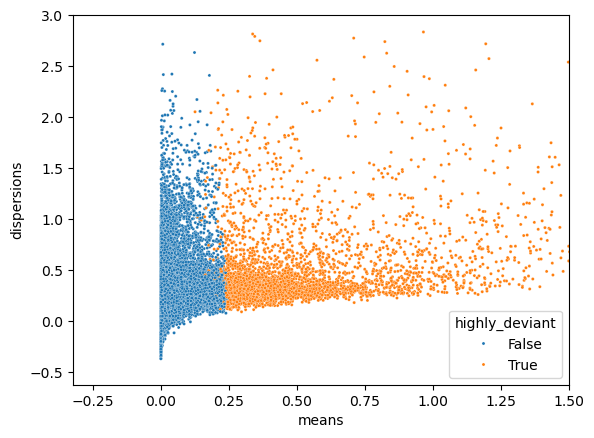

In [19]:
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)
plt.show()

In [ ]:
# save data - takes 39 mins
out_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_feature_selection.h5ad"
adata.write(out_file)

# Dimensionality Reduction

See: https://pair-code.github.io/understanding-umap/


In [28]:
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
# load data - takes 5 mins, 6+Gb
in_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_feature_selection.h5ad"
adata = sc.read_h5ad(in_file)

In [7]:
# set default to normalized counts
adata.X = adata.layers["log1p_norm"]

## PCA

In [10]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
# remember genes marked as highly deviant = top 4000 genes
adata.var["highly_variable"] = adata.var["highly_deviant"]
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


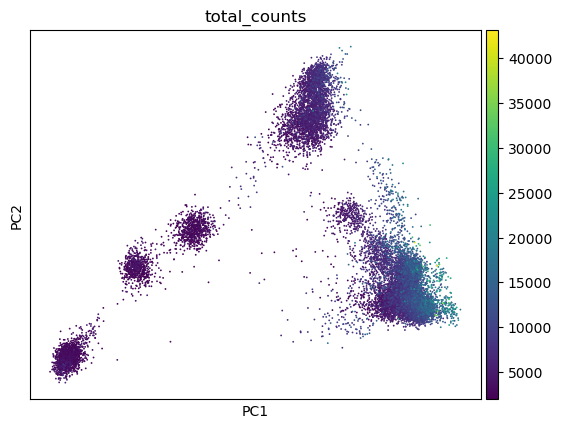

In [11]:
sc.pl.pca_scatter(adata, color="total_counts")

## t-SNE

To see various visualizations, calculate at different perplexities (5-2000?)

In [13]:
# generate t-sne
# use pca representations of data for tsne
sc.tl.tsne(adata, use_rep="X_pca")


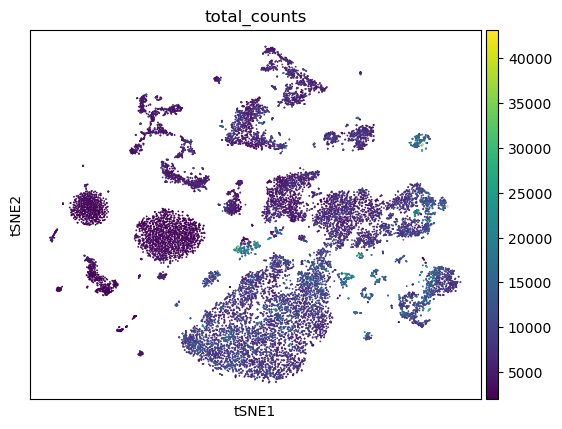

In [14]:
sc.pl.tsne(adata, color="total_counts")

## UMAP

To see different visualizations:
- vary n_neighbors (5-200)
- vary min_dist (0-1)


In [ ]:
# calculate neighborhood graph to be used by umap
sc.pp.neighbors(adata) # uses PCA to generate


In [ ]:

sc.tl.umap(adata)

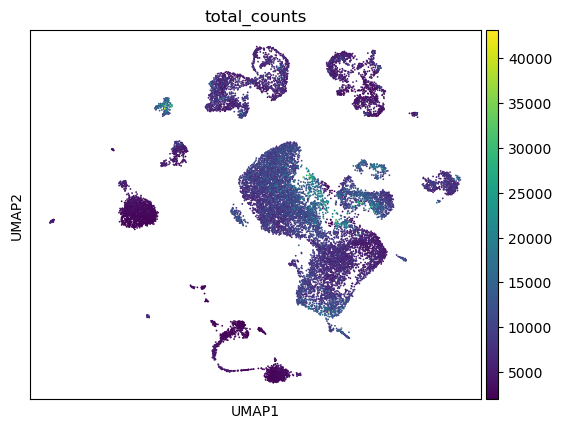

In [26]:
sc.pl.umap(adata, color="total_counts")

Calculating UMAP for n_neigh=5 and min_dist=0
Calculating UMAP for n_neigh=5 and min_dist=0.01
Calculating UMAP for n_neigh=5 and min_dist=0.05
Calculating UMAP for n_neigh=5 and min_dist=0.1
Calculating UMAP for n_neigh=5 and min_dist=0.5
Calculating UMAP for n_neigh=5 and min_dist=1
Calculating UMAP for n_neigh=15 and min_dist=0
Calculating UMAP for n_neigh=15 and min_dist=0.01
Calculating UMAP for n_neigh=15 and min_dist=0.05
Calculating UMAP for n_neigh=15 and min_dist=0.1
Calculating UMAP for n_neigh=15 and min_dist=0.5
Calculating UMAP for n_neigh=15 and min_dist=1
Calculating UMAP for n_neigh=30 and min_dist=0
Calculating UMAP for n_neigh=30 and min_dist=0.01
Calculating UMAP for n_neigh=30 and min_dist=0.05
Calculating UMAP for n_neigh=30 and min_dist=0.1
Calculating UMAP for n_neigh=30 and min_dist=0.5
Calculating UMAP for n_neigh=30 and min_dist=1
Calculating UMAP for n_neigh=50 and min_dist=0
Calculating UMAP for n_neigh=50 and min_dist=0.01
Calculating UMAP for n_neigh=50 a

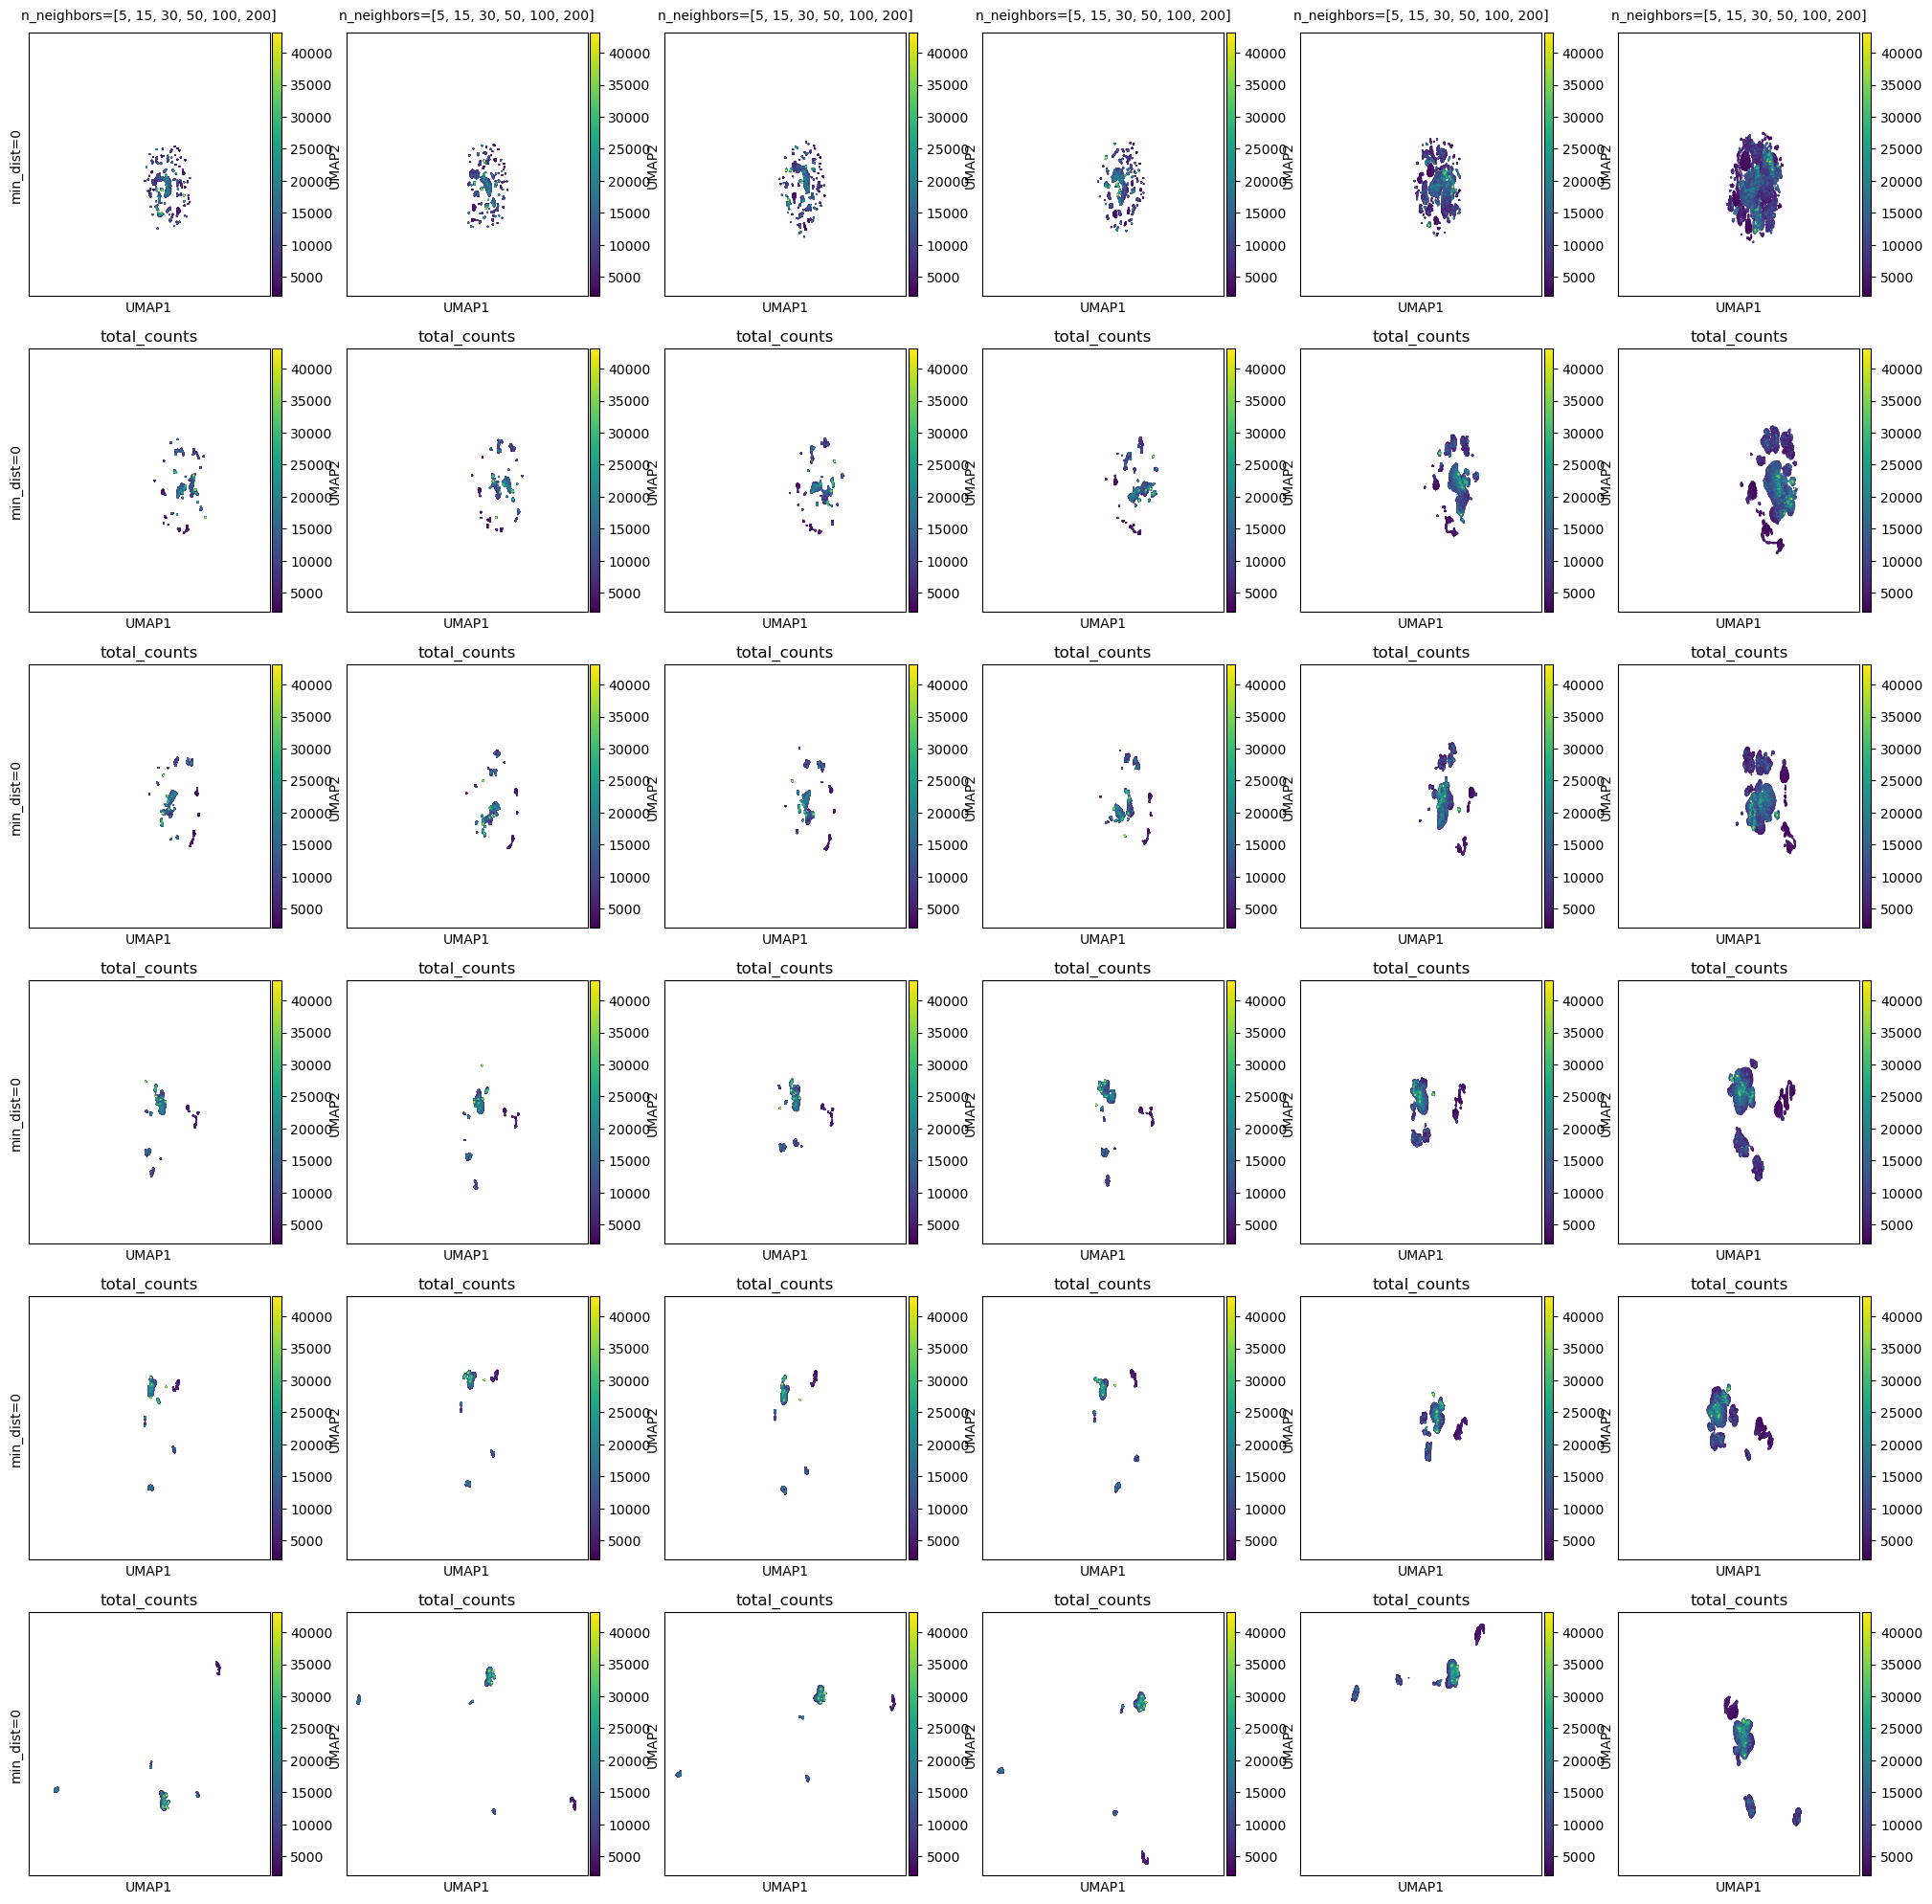

In [ ]:
# generate grid of umap w/ min_dist and n_neighbors parameters...
n_neighbors = [15, 50, 100, 200, 500, 1000]
min_dists = [0, 0.01, 0.05, 0.1, 0.5, 1]

fig, axs = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(20,20))

for i in range(len(n_neighbors)):
    n_neighbor = n_neighbors[i]
    for j in range(len(min_dists)):
        min_dist = min_dists[j]

        ax = axs[i, j]

        print(f"Calculating UMAP for n_neigh={n_neighbor} and min_dist={min_dist}")

        # generate different neighborhood graph w/ diff number of neighbors
        sc.pp.neighbors(adata, n_neighbors=n_neighbor) # uses PCA to generate

        # Compute UMAP with current parameters
        sc.tl.umap(adata, min_dist=min_dist)

        # plot
        sc.pl.umap(
            adata,
            color='total_counts',  # Change this to your preferred coloring
            ax=ax,
            show=False,
            title=None,
            legend_loc=None
        )

        # Add parameter labels on the edges
        if i == 0:
            ax.set_title(f'n_neighbors={n_neighbor}', 
                        fontsize=10, pad=10)
        if j == 0:
            ax.set_ylabel(f'min_dist={min_dist}', fontsize=10)

plt.show()

## Look at QC metrics

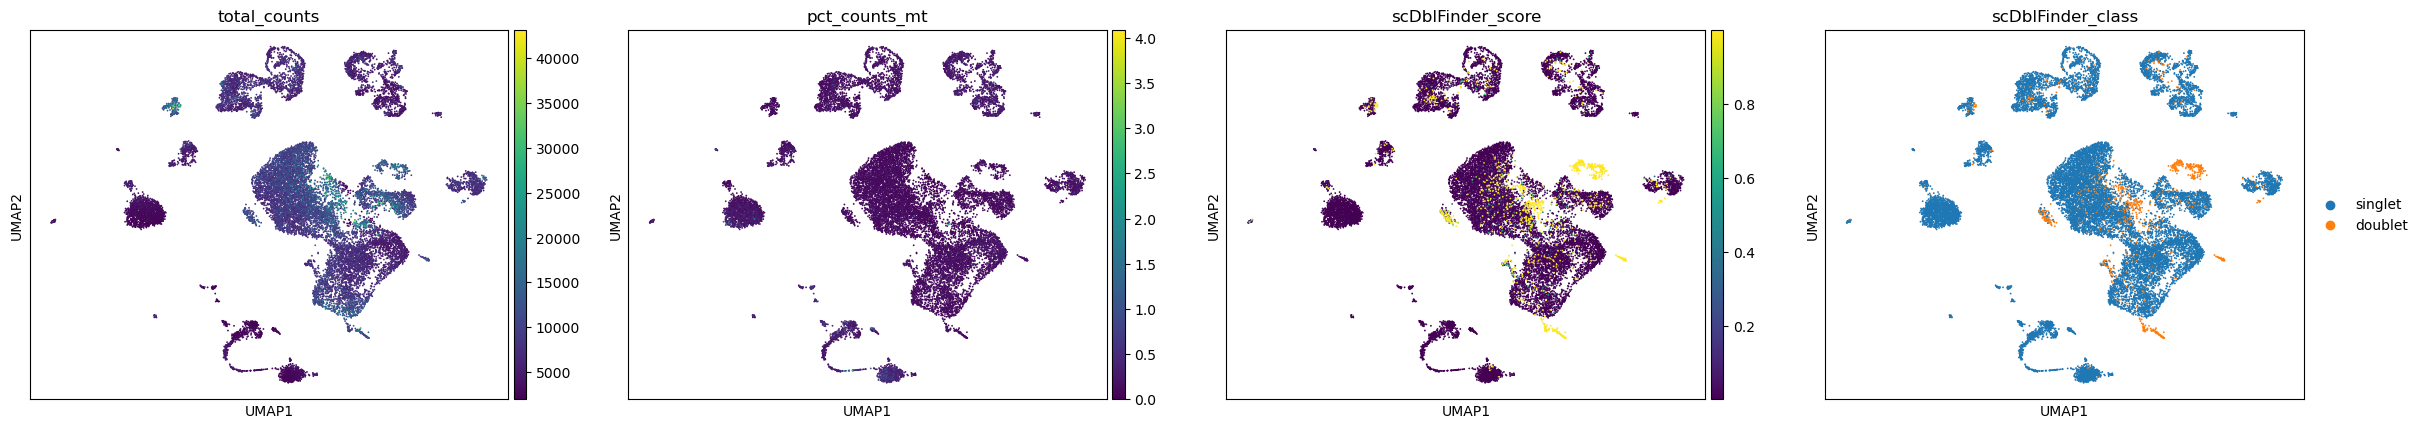

In [32]:
sc.pp.neighbors(adata) # uses PCA to generate
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class"],
)

In [ ]:
out_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_dim_reduction.h5ad"
adata.write(out_file)

## Clustering
- Use leiden clustering

In [ ]:
in_file = "/Volumes/S2D1/Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/data/post_dim_reduction.h5ad"
adata = sc.read_h5ad(in_file)

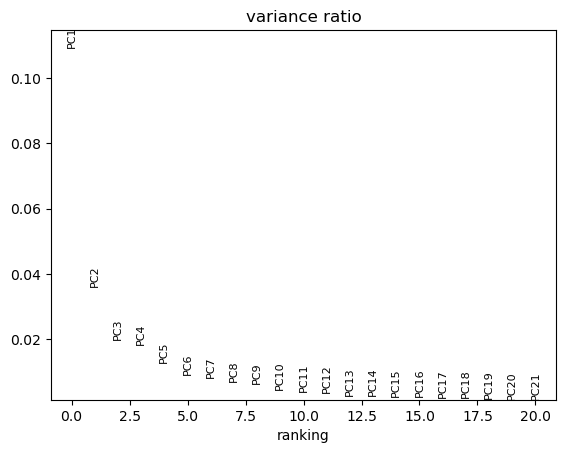

In [33]:
# visualize pca variance
sc.pl.pca_variance_ratio(adata, n_pcs=20)

In [34]:
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)

In [35]:
sc.tl.leiden(adata) # default resolution is 1

/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_33561/2944124350.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata) # default resolution is 1


In [36]:
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

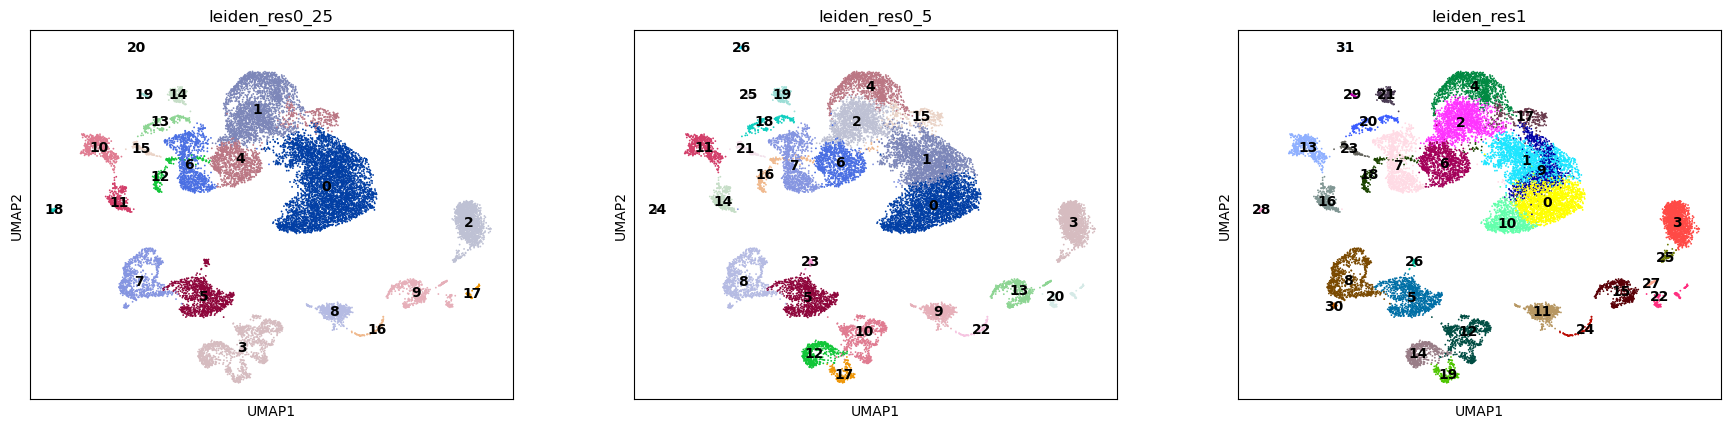

In [37]:
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

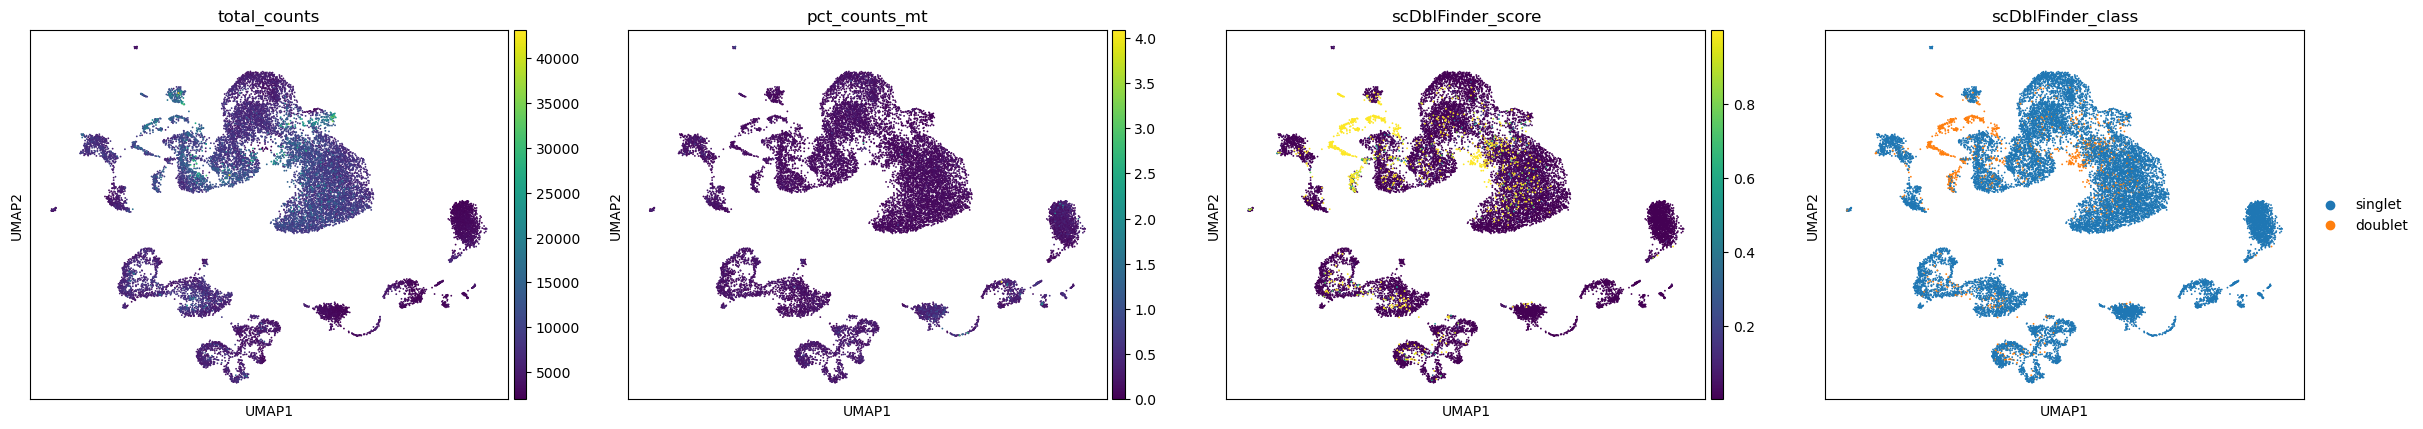

In [38]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class"],
)

# Annotate Clusters

## Manual Annotation

### Visualize marker genes
- take a look at DEG for each cluster, see intersection with marker genes?

## Automated annotation
- Integrate w/ hierarchical clustering(?) with allen mouse 10x data
- See: https://github.com/AllenInstitute/cell_type_mapper?tab=readme-ov-file
- Data downloaded to map cells: https://allen-brain-cell-atlas.s3.us-west-2.amazonaws.com/index.html#mapmycells/WMB-10X/20240831/
    - `wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WMB-10X/20240831/mouse_markers_230821.json ./`
    - `wget https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/mapmycells/WMB-10X/20240831/precomputed_stats_ABC_revision_230821.h5 ./`

